In [2]:
!pip -q install kagglehub opencv-python


In [3]:
import kagglehub, os, glob, random
import numpy as np
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam

path = kagglehub.dataset_download("anasmohammedtahir/covidqu")
print("Dataset path:", path)


100%|██████████| 1.15G/1.15G [00:53<00:00, 23.1MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/anasmohammedtahir/covidqu/versions/7


In [4]:
IMG_EXTS = (".png",".jpg",".jpeg",".bmp")

def find_files(root):
    files=[]
    for e in IMG_EXTS:
        files+=glob.glob(os.path.join(root,"**",f"*{e}"),recursive=True)
    return files

files=find_files(path)
images=[f for f in files if "mask" not in f.lower()]
masks =[f for f in files if "mask" in f.lower()]

def stem(p): return os.path.splitext(os.path.basename(p))[0]
mask_map={stem(m):m for m in masks}
pairs=[(i,mask_map[stem(i)]) for i in images if stem(i) in mask_map]

print("Matched pairs:",len(pairs))


Matched pairs: 39746


In [12]:
IMG_SIZE = 256

class CovidDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        msk = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        msk = cv2.resize(msk, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

        # normalize
        img = img.astype("float32") / 255.0
        msk = (msk > 0).astype("float32")

        return (
            torch.tensor(img, dtype=torch.float32).unsqueeze(0),
            torch.tensor(msk, dtype=torch.float32).unsqueeze(0)
        )


In [13]:
class DoubleConv(nn.Module):
    def __init__(self,i,o):
        super().__init__()
        self.net=nn.Sequential(
            nn.Conv2d(i,o,3,1,1),nn.ReLU(),
            nn.Conv2d(o,o,3,1,1),nn.ReLU())
    def forward(self,x): return self.net(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1=DoubleConv(1,32)
        self.p1=nn.MaxPool2d(2)
        self.d2=DoubleConv(32,64)
        self.p2=nn.MaxPool2d(2)
        self.b =DoubleConv(64,128)
        self.u2=nn.ConvTranspose2d(128,64,2,2)
        self.c2=DoubleConv(128,64)
        self.u1=nn.ConvTranspose2d(64,32,2,2)
        self.c1=DoubleConv(64,32)
        self.o =nn.Conv2d(32,1,1)
    def forward(self,x):
        x1=self.d1(x); x2=self.d2(self.p1(x1))
        xb=self.b(self.p2(x2))
        x=self.u2(xb); x=self.c2(torch.cat([x,x2],1))
        x=self.u1(x);  x=self.c1(torch.cat([x,x1],1))
        return self.o(x)

device="cuda" if torch.cuda.is_available() else "cpu"
model=UNet().to(device)
opt=Adam(model.parameters(),1e-3)
loss_fn=nn.BCEWithLogitsLoss()


In [14]:
from torch.utils.data import DataLoader
import random

# shuffle + split
random.shuffle(pairs)
split = int(0.8 * len(pairs))

train_pairs = pairs[:split]
val_pairs   = pairs[split:]

train_ds = CovidDataset(train_pairs)
val_ds   = CovidDataset(val_pairs)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False)

print("Train:", len(train_ds), "| Val:", len(val_ds))


Train: 31796 | Val: 7950


In [15]:
for e in range(5):
    model.train()
    for x,y in train_loader:
        x,y=x.to(device),y.to(device)
        opt.zero_grad()
        loss=loss_fn(model(x),y)
        loss.backward(); opt.step()
    print("Epoch",e+1)

torch.save(model.state_dict(),"best_unet.pth")
print("Saved best_unet.pth")


Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Saved best_unet.pth


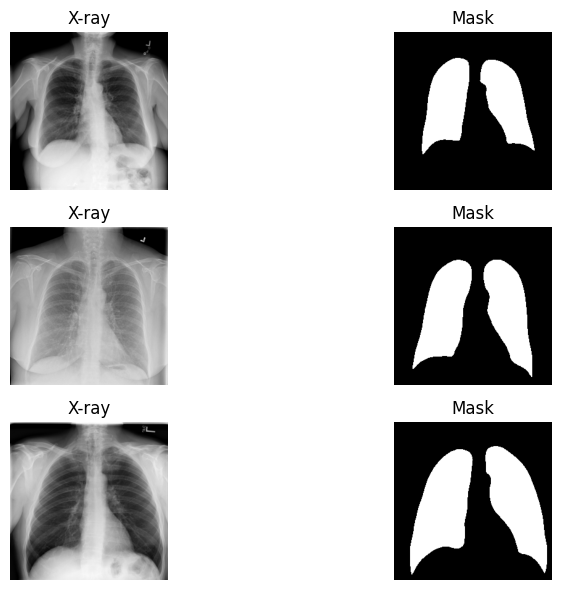

Saved: dataset_samples.png


In [16]:
# draw img to intro dataset
import matplotlib.pyplot as plt
import cv2, random
import numpy as np

def show_samples(pairs, k=4):
    idxs = random.sample(range(len(pairs)), k=min(k, len(pairs)))
    plt.figure(figsize=(10, 6))
    for i, idx in enumerate(idxs, 1):
        img_path, mask_path = pairs[idx]
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        msk = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        msk = cv2.resize(msk, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
        msk = (msk > 0).astype(np.uint8)

        plt.subplot(k, 2, 2*i-1)
        plt.imshow(img, cmap="gray")
        plt.title("X-ray")
        plt.axis("off")

        plt.subplot(k, 2, 2*i)
        plt.imshow(msk, cmap="gray")
        plt.title("Mask")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig("dataset_samples.png", dpi=200)
    plt.show()

show_samples(pairs, k=3)
print("Saved: dataset_samples.png")


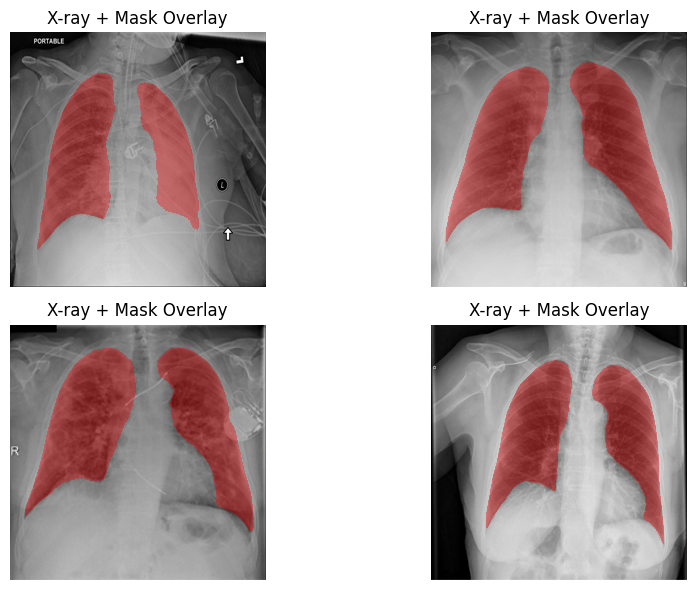

Saved: mask_overlay.png


In [17]:
#overlay mask > medicine
import matplotlib.pyplot as plt
import cv2, random
import numpy as np

def show_overlay(pairs, k=4):
    idxs = random.sample(range(len(pairs)), k=min(k, len(pairs)))
    plt.figure(figsize=(10, 6))

    for i, idx in enumerate(idxs, 1):
        img_path, mask_path = pairs[idx]
        img = cv2.imread(img_path, 0)
        msk = cv2.imread(mask_path, 0)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        msk = cv2.resize(msk, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
        msk = (msk > 0).astype(np.uint8)

        # overlay: đỏ
        img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        overlay = img_rgb.copy()
        overlay[msk == 1] = [255, 0, 0]  # red mask

        alpha = 0.35
        blended = (img_rgb*(1-alpha) + overlay*alpha).astype(np.uint8)

        plt.subplot(2, 2, i)
        plt.imshow(blended)
        plt.title("X-ray + Mask Overlay")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig("mask_overlay.png", dpi=200)
    plt.show()

show_overlay(pairs, k=4)
print("Saved: mask_overlay.png")


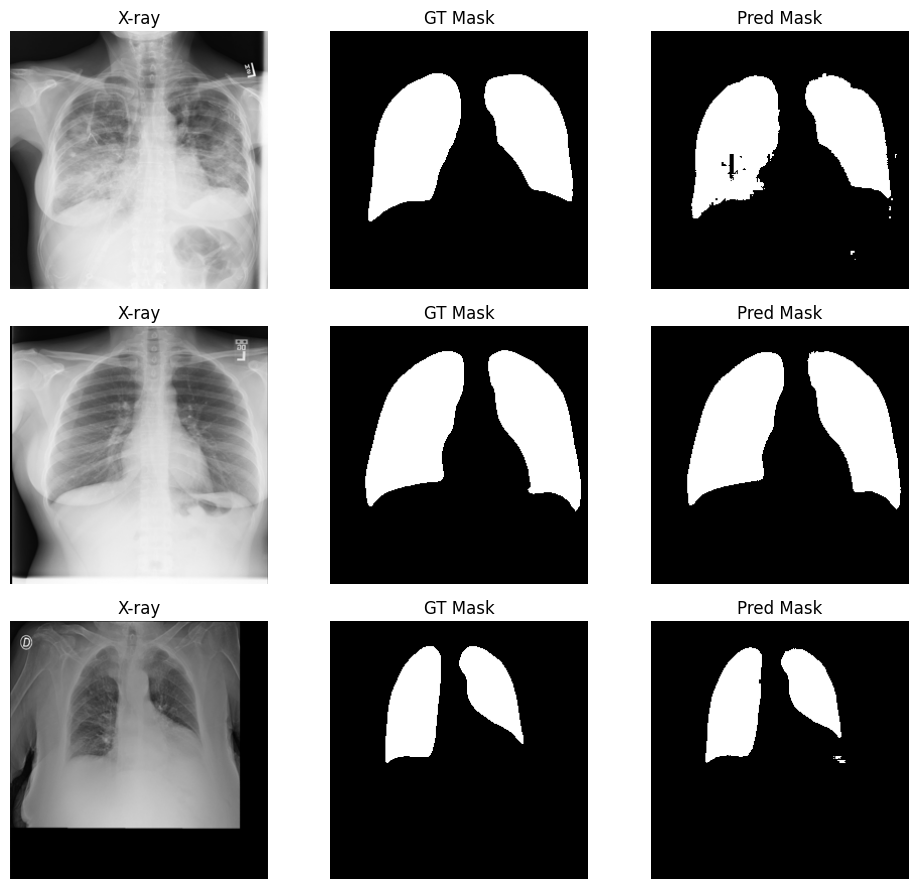

Saved: predictions_grid.png


In [18]:
#GT vs pred
import matplotlib.pyplot as plt
import torch
import cv2, random
import numpy as np

model.eval()

def show_predictions(pairs, k=3):
    idxs = random.sample(range(len(pairs)), k=min(k, len(pairs)))
    plt.figure(figsize=(10, 3*k))

    for i, idx in enumerate(idxs, 1):
        img_path, mask_path = pairs[idx]
        img = cv2.imread(img_path, 0)
        msk = cv2.imread(mask_path, 0)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        msk = cv2.resize(msk, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
        gt = (msk > 0).astype(np.float32)

        x = (img.astype(np.float32)/255.0)
        x_t = torch.tensor(x).unsqueeze(0).unsqueeze(0).to(device)

        with torch.no_grad():
            pred = torch.sigmoid(model(x_t)).cpu().numpy()[0,0]
        pred_bin = (pred > 0.5).astype(np.float32)

        plt.subplot(k, 3, 3*i-2)
        plt.imshow(img, cmap="gray"); plt.axis("off"); plt.title("X-ray")

        plt.subplot(k, 3, 3*i-1)
        plt.imshow(gt, cmap="gray"); plt.axis("off"); plt.title("GT Mask")

        plt.subplot(k, 3, 3*i)
        plt.imshow(pred_bin, cmap="gray"); plt.axis("off"); plt.title("Pred Mask")

    plt.tight_layout()
    plt.savefig("predictions_grid.png", dpi=200)
    plt.show()

show_predictions(val_pairs, k=3)
print("Saved: predictions_grid.png")
